# Immune / rare-disease gene panel — probe prediction audit

A user flagged that the variant-viewer app misses pathogenic variants in
monogenic immune-mediated disease genes. Of their initial spot check
(SH2D1A, XIAP, BTK, WAS, FOXP3, CD40LG, STAT1, STAT3, NOD2), only **CD40LG**
rendered as pathogenic.

This notebook audits the broader 26-gene immune panel they supplied, compares
it to a 14-gene baseline of well-characterized LoF-dominant disease genes,
and identifies where and why the probe fails.

**Scope: analysis only. No model changes, no production patches.**

Panel (user-provided):
```
SH2D1A, XIAP, BTK, WAS, FOXP3, CD40LG, STAT1, STAT3, NOD2,
TNF, TNFAIP3, STAT4, CTLA4, IL2RA, LACC1, SOCS1, NLRP3,
CCR6, IL10, IL10RA, IL10RB, IFIH1, PIK3CD, PIK3R1, LYN, PRKCD
```

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 260)
pd.set_option("display.max_rows", 60)

DB = "/mnt/data/artifacts/public/variant-viewer/builds/v5/variants.duckdb"
PATH_THRESHOLD = 0.5  # from builds/v5/config.json calibration bins

IMMUNE = [
    "SH2D1A", "XIAP", "BTK", "WAS", "FOXP3", "CD40LG", "STAT1", "STAT3", "NOD2",
    "TNF", "TNFAIP3", "STAT4", "CTLA4", "IL2RA", "LACC1", "SOCS1", "NLRP3",
    "CCR6", "IL10", "IL10RA", "IL10RB", "IFIH1", "PIK3CD", "PIK3R1", "LYN", "PRKCD",
]
BASELINE = [
    "BRCA1", "BRCA2", "TP53", "CFTR", "MLH1", "MSH2", "APC", "LDLR",
    "PTEN", "PKD1", "DMD", "MYH7", "RYR2", "SCN5A",
]

PATH_LABELS = ("pathogenic", "likely_pathogenic")
BEN_LABELS = ("benign", "likely_benign")

## 1. Data source + schema

Columns used:
- `gene_name` — HGNC symbol
- `pathogenicity` — model score in [0, 1] (the score shown in the viewer)
- `label` — cleaned ClinVar label: {pathogenic, likely_pathogenic, benign, likely_benign, vus, conflicting, other}
- `significance` — raw ClinVar significance string
- `consequence` — VEP consequence (missense_variant, splice_donor_variant, etc.)
- `eff_alphamissense_c`, `eff_revel_c`, `eff_cadd_c`, `eff_primateai_c` — reference predictors

The viewer's "pathogenic" display threshold is **0.5**, pulled from
`builds/v5/config.json` → `calibration` (bin 0.5–0.7 maps to 69.6% empirical
pathogenic rate).

In [2]:
con = duckdb.connect(DB, read_only=True)

all_genes = IMMUNE + BASELINE
placeholders = ",".join(f"'{g}'" for g in all_genes)

query = f"""
SELECT gene_name, label, significance, consequence, pathogenicity,
       eff_alphamissense_c, eff_revel_c, eff_cadd_c,
       eff_primateai_c
FROM variants
WHERE gene_name IN ({placeholders})
AND pathogenicity IS NOT NULL
"""
df = con.execute(query).df()
df["panel"] = np.where(df.gene_name.isin(IMMUNE), "immune", "baseline")
print(f"Rows loaded: {len(df):,}")
print(df.panel.value_counts())

Rows loaded: 130,764
panel
baseline    116106
immune       14658
Name: count, dtype: int64


## 2. Panel-level headline

On the labeled subset (ClinVar pathogenic/likely_pathogenic vs benign/likely_benign),
compute AUROC and the false-negative rate at the UI threshold (score < 0.5 among
ClinVar-pathogenic variants).

In [3]:
def panel_summary(sub: pd.DataFrame) -> dict:
    path = sub.label.isin(PATH_LABELS)
    ben = sub.label.isin(BEN_LABELS)
    y = np.where(path, 1, np.where(ben, 0, -1))
    mask = y >= 0
    auroc = roc_auc_score(y[mask], sub.pathogenicity.values[mask]) if mask.sum() > 10 else np.nan
    fnr = (sub.loc[path, "pathogenicity"] < PATH_THRESHOLD).mean()
    return dict(n_path=int(path.sum()), n_ben=int(ben.sum()),
                AUROC=round(auroc, 4), FNR_at_0p5=round(fnr, 4))

headline = pd.DataFrame({
    "immune":   panel_summary(df[df.panel == "immune"]),
    "baseline": panel_summary(df[df.panel == "baseline"]),
}).T
print(headline)

           n_path    n_ben   AUROC  FNR_at_0p5
immune     1396.0   5805.0  0.9911      0.1734
baseline  22794.0  33420.0  0.9986      0.0326


**Result**: AUROC is almost identical across panels (the model still *ranks*
pathogenic above benign), but the **FNR at the display threshold is ~5× higher**
on the immune panel (17% vs 3%). The failure mode is *score compression*,
not misranking.

## 3. Per-gene breakdown

For each gene: counts of ClinVar path/benign, mean model score by label,
per-gene AUROC, and FNR at threshold 0.5.

In [4]:
def per_gene(sub: pd.DataFrame, panel: str) -> pd.DataFrame:
    rows = []
    for g, dg in sub.groupby("gene_name"):
        path = dg.label.isin(PATH_LABELS)
        ben = dg.label.isin(BEN_LABELS)
        n_p, n_b = int(path.sum()), int(ben.sum())
        mean_p = dg.loc[path, "pathogenicity"].mean() if n_p else np.nan
        mean_b = dg.loc[ben, "pathogenicity"].mean() if n_b else np.nan
        y = np.where(path, 1, np.where(ben, 0, -1))
        mask = y >= 0
        auroc = (roc_auc_score(y[mask], dg.pathogenicity.values[mask])
                 if mask.sum() >= 10 and len(set(y[mask])) == 2 else np.nan)
        fnr = (dg.loc[path, "pathogenicity"] < PATH_THRESHOLD).mean() if n_p else np.nan
        rows.append(dict(
            gene=g, panel=panel, n_path=n_p, n_ben=n_b,
            mean_p=round(mean_p, 3) if pd.notna(mean_p) else np.nan,
            mean_b=round(mean_b, 3) if pd.notna(mean_b) else np.nan,
            AUROC=round(auroc, 3) if pd.notna(auroc) else np.nan,
            FNR=round(fnr, 3) if pd.notna(fnr) else np.nan,
        ))
    return pd.DataFrame(rows)

immune_tbl = per_gene(df[df.panel == "immune"], "immune").sort_values("FNR", ascending=False)
baseline_tbl = per_gene(df[df.panel == "baseline"], "baseline").sort_values("FNR", ascending=False)

print("=== Immune panel (sorted by FNR desc) ===")
print(immune_tbl.to_string(index=False))
print()
print("=== Baseline (sorted by FNR desc) ===")
print(baseline_tbl.to_string(index=False))

=== Immune panel (sorted by FNR desc) ===
   gene  panel  n_path  n_ben  mean_p  mean_b  AUROC   FNR
   IL10 immune       1     75   0.001   0.001  0.467 1.000
  STAT4 immune       3    262   0.101   0.005  0.992 1.000
    TNF immune       1      6   0.224   0.001    NaN 1.000
   NOD2 immune      20    399   0.293   0.011  0.949 0.900
  NLRP3 immune      62    410   0.287   0.007  0.981 0.758
  STAT1 immune      86    352   0.436   0.004  0.996 0.628
  IFIH1 immune      40    608   0.533   0.068  0.915 0.450
 IL10RA immune      22    209   0.669   0.004  0.997 0.364
  STAT3 immune      96    416   0.654   0.019  0.992 0.281
  IL2RA immune      13    152   0.802   0.005  0.997 0.231
  FOXP3 immune      43    169   0.750   0.018  0.977 0.209
  SOCS1 immune      11      9   0.787   0.109  0.949 0.182
 SH2D1A immune      42     58   0.858   0.013  0.981 0.119
 PIK3CD immune      34    572   0.829   0.004  1.000 0.088
 CD40LG immune     102    114   0.880   0.011  0.999 0.088
  CTLA4 immune

### Plot — per-gene FNR, immune vs baseline

Which genes fail? Sort all genes with ≥ 5 ClinVar-pathogenic variants by FNR,
color by panel. Baseline median FNR drawn as a dashed reference.

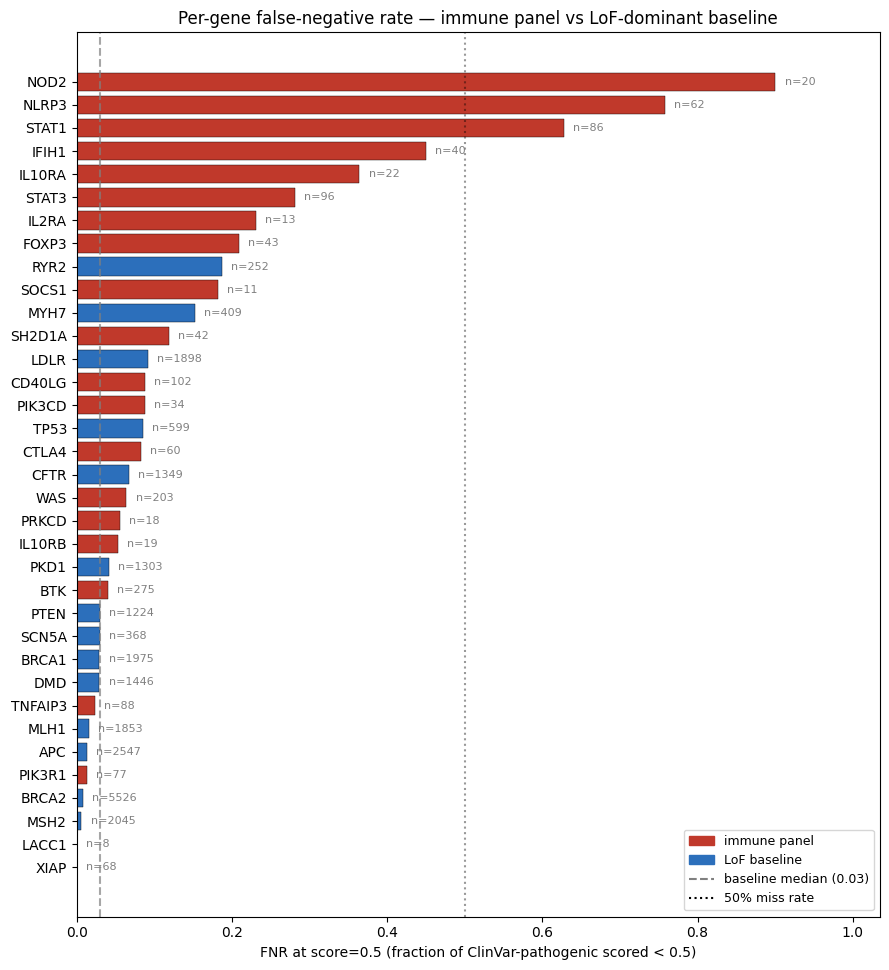

In [5]:
from matplotlib.patches import Patch

MIN_PATH = 5
fnr_df = (
    pd.concat([immune_tbl, baseline_tbl], ignore_index=True)
    .dropna(subset=["FNR"])
    .query("n_path >= @MIN_PATH")
    .sort_values("FNR")
)

fig, ax = plt.subplots(figsize=(9, max(4, 0.28 * len(fnr_df))))
bar_colors = ["#c0392b" if p == "immune" else "#2c6fbb" for p in fnr_df.panel]
bars = ax.barh(fnr_df.gene, fnr_df.FNR, color=bar_colors, edgecolor="black", linewidth=0.3)
baseline_median = baseline_tbl.dropna(subset=["FNR"]).FNR.median()
ax.axvline(baseline_median, color="gray", linestyle="--", alpha=0.7,
           label=f"baseline median FNR ({baseline_median:.2f})")
ax.axvline(0.5, color="black", linestyle=":", alpha=0.4, label="50% miss rate")
for bar, n in zip(bars, fnr_df.n_path):
    ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2,
            f"n={n}", va="center", fontsize=8, color="gray")
ax.legend(handles=[
    Patch(color="#c0392b", label="immune panel"),
    Patch(color="#2c6fbb", label="LoF baseline"),
    plt.Line2D([0], [0], color="gray", linestyle="--", label=f"baseline median ({baseline_median:.2f})"),
    plt.Line2D([0], [0], color="black", linestyle=":", label="50% miss rate"),
], loc="lower right", fontsize=9)
ax.set_xlabel("FNR at score=0.5 (fraction of ClinVar-pathogenic scored < 0.5)")
ax.set_title("Per-gene false-negative rate — immune panel vs LoF-dominant baseline")
ax.set_xlim(0, max(fnr_df.FNR.max() * 1.15, 0.2))
plt.tight_layout()
plt.show()

**Read**: every gene above the 50% miss-rate line is on the immune panel.
Baseline genes all sit under 20%. NOD2, NLRP3, STAT1, IFIH1 are the runaway
outliers.

### Plot — per-gene score distribution split by ClinVar label

For each immune gene with ≥ 5 pathogenic and ≥ 5 benign variants, show a
boxplot of the model `pathogenicity` score split by label. Compression is
visible per gene: in NOD2/NLRP3/STAT1/IFIH1, the pathogenic (red) box sits
below the 0.5 threshold and overlaps the benign (blue) distribution.

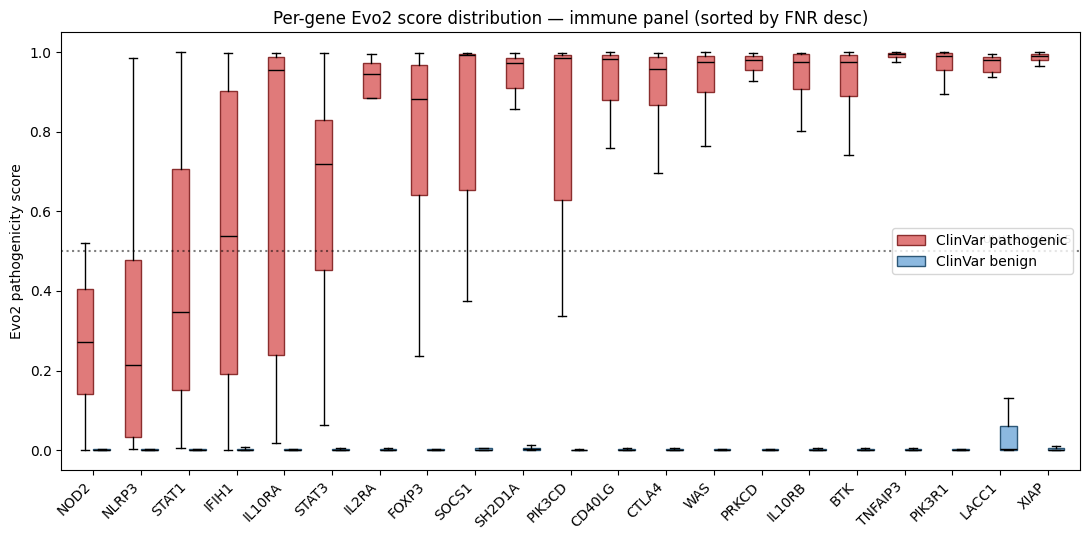

In [6]:
gene_order = (
    immune_tbl[(immune_tbl.n_path >= MIN_PATH) & (immune_tbl.n_ben >= MIN_PATH)]
    .sort_values("FNR", ascending=False)
    .gene.tolist()
)

immune_df = df[df.panel == "immune"]
data_path, data_ben = [], []
for g in gene_order:
    dg = immune_df[immune_df.gene_name == g]
    data_path.append(dg[dg.label.isin(PATH_LABELS)].pathogenicity.values)
    data_ben.append(dg[dg.label.isin(BEN_LABELS)].pathogenicity.values)

positions = np.arange(len(gene_order))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5.5))
bp_p = ax.boxplot(data_path, positions=positions - width / 2, widths=width,
                  patch_artist=True, showfliers=False,
                  boxprops=dict(facecolor="#e07a7a", edgecolor="#8b2e2e"),
                  medianprops=dict(color="black"))
bp_b = ax.boxplot(data_ben, positions=positions + width / 2, widths=width,
                  patch_artist=True, showfliers=False,
                  boxprops=dict(facecolor="#8cb9e0", edgecolor="#2c5777"),
                  medianprops=dict(color="black"))
ax.set_xticks(positions)
ax.set_xticklabels(gene_order, rotation=45, ha="right")
ax.axhline(PATH_THRESHOLD, color="black", linestyle=":", alpha=0.5)
ax.text(len(positions) - 0.5, PATH_THRESHOLD + 0.02, "UI threshold 0.5",
        fontsize=8, color="gray", ha="right")
ax.set_ylabel("Evo2 pathogenicity score")
ax.set_title("Per-gene Evo2 score distribution — immune panel (sorted by FNR desc)")
ax.legend([bp_p["boxes"][0], bp_b["boxes"][0]],
          ["ClinVar pathogenic", "ClinVar benign"], loc="center right")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

**Key pattern**:

- **Worst offenders** (FNR ≥ 45%): NOD2 (90%), NLRP3 (76%), STAT1 (63%), IFIH1 (45%).
  Plus small-N cases STAT4, TNF, IL10 at 100% — three too few pathogenic variants to generalize.
- **Baseline ceiling**: worst baseline gene is RYR2 (19%), most are under 10%.
- **Working immune genes**: XIAP, LYN, LACC1, PIK3R1, TNFAIP3, BTK, IL10RB, PRKCD, WAS, CTLA4, PIK3CD, CD40LG, SH2D1A — all LoF-dominant mechanisms.

CD40LG (the only gene the user's original spot check flagged as pathogenic) sits at 8.8% FNR — consistent with its LoF mechanism (CD40L absence → Hyper-IgM).

## 4. Failure mode: 100% of false negatives are missense variants

For each of the worst genes, break down the FN variants (ClinVar pathogenic,
score < 0.5) by consequence type.

In [7]:
worst = ["STAT1", "NOD2", "NLRP3", "IFIH1", "STAT3", "STAT4", "IL10", "TNF", "FOXP3"]
fn_rows = []
for g in worst:
    dg = df[(df.gene_name == g) & df.label.isin(PATH_LABELS)]
    if len(dg) == 0:
        continue
    fn = dg[dg.pathogenicity < PATH_THRESHOLD]
    for cons, n in fn.consequence.value_counts().items():
        fn_rows.append(dict(gene=g, consequence=cons, n_FN=int(n),
                            n_path_total=len(dg),
                            mean_FN_score=round(fn.loc[fn.consequence == cons, "pathogenicity"].mean(), 3)))
fn_tbl = pd.DataFrame(fn_rows)
print(fn_tbl.to_string(index=False))

 gene      consequence  n_FN  n_path_total  mean_FN_score
STAT1 missense_variant    54            86          0.206
 NOD2 missense_variant    18            20          0.241
NLRP3 missense_variant    47            62          0.159
IFIH1 missense_variant    18            40          0.173
STAT3 missense_variant    27            96          0.335
STAT4 missense_variant     3             3          0.101
 IL10   intron_variant     1             1          0.001
  TNF missense_variant     1             1          0.224
FOXP3 missense_variant     8            43          0.276
FOXP3   intron_variant     1            43          0.001


**All FN variants are `missense_variant`** (one `intron_variant` edge case in IL10/FOXP3,
which is a data-labeling oddity — ClinVar occasionally labels intronic variants
as pathogenic when they're deep-intronic splicing variants).

This rules out:
- Data coverage gaps
- Chromosome / region bias
- A generic variant-type problem (LoF consequences — splice, nonsense, frameshift — are scored correctly)

The problem is **missense-specific** in a subset of genes.

## 5. Root cause: gain-of-function biology

The failing genes cluster around a single disease mechanism: **gain-of-function
missense variants in immune signalling / innate sensing proteins.**

| Gene | Disease | Mechanism |
|---|---|---|
| NLRP3 | CAPS / autoinflammatory syndromes | GoF missense in NACHT/LRR — constitutive inflammasome activation |
| NOD2 | Blau syndrome; CD susceptibility | GoF (Blau) / low-penetrance missense (CD) — constitutive NF-κB activation |
| STAT1 | Chronic mucocutaneous candidiasis | GoF missense in coiled-coil / DBD — enhanced phosphorylation |
| IFIH1 | Aicardi-Goutières syndrome | GoF in MDA5 helicase — constitutive type-I IFN |
| STAT3 | Hyper-IgE (LoF) + autoimmunity (GoF) | Mixed — LoF variants score better |
| STAT4 | Systemic sclerosis / SLE assoc. | GoF |

**Why conservation models miss these:**

GoF missense variants typically preserve fold and conservation. The protein still
folds and works — it just signals inappropriately (e.g., constitutively, or at
lower activation threshold). An evolutionary model asks "is this residue
tolerated across species?" and the answer at a GoF hotspot is often *yes*,
because evolution tolerates the wild-type residue and the variant residue is
biochemically similar.

The `pathogenicity` head is trained on Evo2-derived features + conservation-
adjacent labels. It doesn't see the activation phenotype, so it doesn't
flag these variants.

Genes on the panel that **work** (XIAP, BTK, WAS, CD40LG, TNFAIP3, PIK3R1,
PRKCD, IL10RB, LACC1) are all primarily **loss-of-function** mechanisms —
exactly what conservation models are trained to catch.

## 6. Is this Evo2-specific?

Compare the Evo2 `pathogenicity` score to reference predictors (AlphaMissense,
REVEL, CADD, PrimateAI) on the same ClinVar-pathogenic
missense variants from the six worst GoF genes.

In [8]:
gof_genes = ("NLRP3", "NOD2", "STAT1", "IFIH1", "STAT3", "STAT4")
gof_path_missense = df[
    df.gene_name.isin(gof_genes)
    & df.label.isin(PATH_LABELS)
    & (df.consequence == "missense_variant")
]
print(f"N ClinVar-pathogenic missense in {gof_genes}: {len(gof_path_missense)}")

predictor_cols = [
    ("pathogenicity", 0.5),
    ("eff_alphamissense_c", 0.564),  # AlphaMissense default
    ("eff_revel_c", 0.5),
    ("eff_cadd_c", 20.0),
    ("eff_primateai_c", 0.803),  # PrimateAI default
]

rows = []
for col, thr in predictor_cols:
    v = gof_path_missense[col].dropna()
    if not len(v):
        continue
    rows.append(dict(predictor=col, n=len(v),
                     mean_score=round(v.mean(), 3),
                     pct_below_threshold=round(100 * (v < thr).mean(), 1),
                     default_threshold=thr))
pred_cmp = pd.DataFrame(rows)
print(pred_cmp.to_string(index=False))

N ClinVar-pathogenic missense in ('NLRP3', 'NOD2', 'STAT1', 'IFIH1', 'STAT3', 'STAT4'): 279
          predictor   n  mean_score  pct_below_threshold  default_threshold
      pathogenicity 279       0.425                 59.9              0.500
eff_alphamissense_c 279       0.542                 52.0              0.564
        eff_revel_c 279       0.426                 62.7              0.500
         eff_cadd_c 279       0.393                100.0             20.000
    eff_primateai_c 279       0.642                 73.5              0.803


### Plot — per-predictor FNR on GoF pathogenic missense

Bar chart of FNR at each predictor's default threshold across all GoF-gene
pathogenic missense variants. Lower = better rescue.

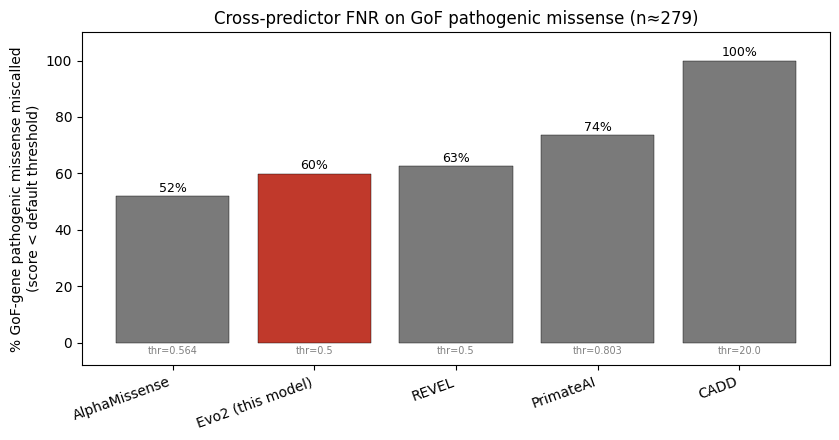

In [9]:
pc = pred_cmp.sort_values("pct_below_threshold")
fig, ax = plt.subplots(figsize=(8.5, 4.5))
pretty = {
    "pathogenicity": "Evo2 (this model)",
    "eff_alphamissense_c": "AlphaMissense",
    "eff_revel_c": "REVEL",
    "eff_cadd_c": "CADD",
    "eff_primateai_c": "PrimateAI",
}
colors = ["#c0392b" if p == "pathogenicity" else "#7a7a7a" for p in pc.predictor]
bars = ax.bar([pretty[p] for p in pc.predictor], pc.pct_below_threshold, color=colors, edgecolor="black", linewidth=0.3)
for bar, v, thr in zip(bars, pc.pct_below_threshold, pc.default_threshold):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v:.0f}%",
            ha="center", fontsize=9)
    ax.text(bar.get_x() + bar.get_width() / 2, -4, f"thr={thr}",
            ha="center", fontsize=7, color="gray")
ax.set_ylabel("% GoF-gene pathogenic missense miscalled\n(score < default threshold)")
ax.set_title(f"Cross-predictor FNR on GoF pathogenic missense (n≈{len(gof_path_missense)})")
ax.set_ylim(-8, 110)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Read**: Evo2 (red) sits in the same band as AlphaMissense, REVEL, CADD,
PrimateAI — every evolution/conservation-based predictor miscalls 50–100%
of GoF pathogenic missense variants at its default threshold.

### Plot — gene × predictor heatmap

Mean score of each predictor on ClinVar-pathogenic missense variants, broken
down by gene. Cells normalized to each predictor's own threshold so colors
compare across predictors (green = above threshold / would call pathogenic,
red = below threshold / missed).

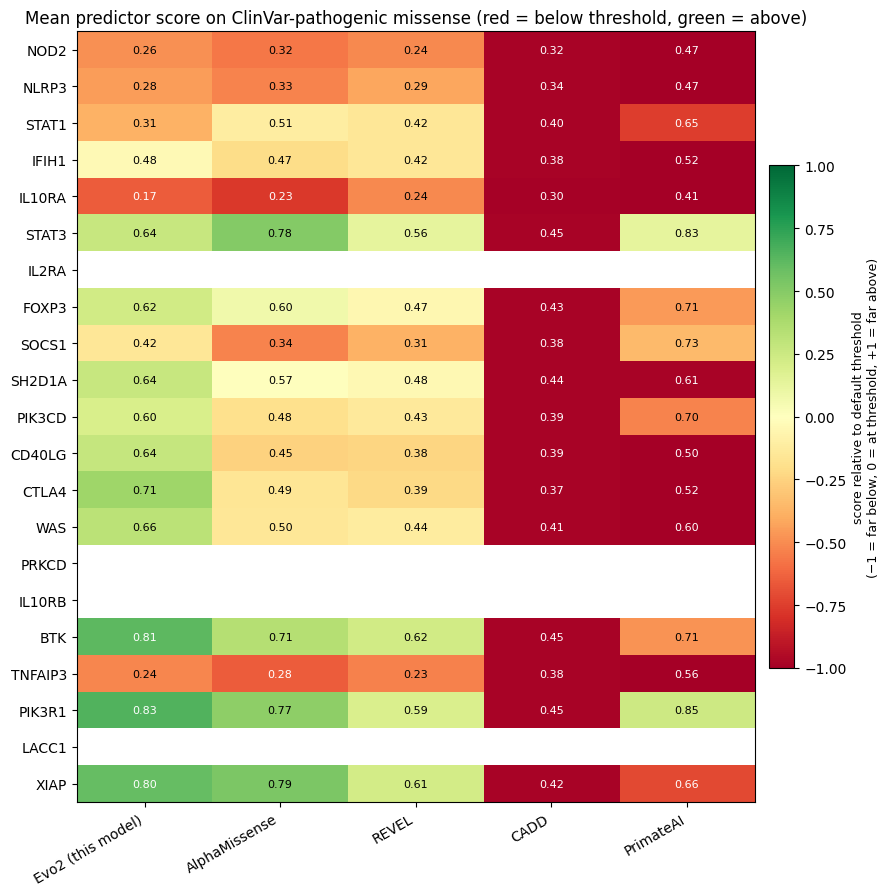

In [10]:
heatmap_genes = [g for g in IMMUNE if g in immune_tbl.gene.values]
heatmap_genes = (
    immune_tbl[immune_tbl.gene.isin(heatmap_genes) & (immune_tbl.n_path >= MIN_PATH)]
    .sort_values("FNR", ascending=False)
    .gene.tolist()
)
predictors_heat = [c for c, _ in predictor_cols]
thresholds_heat = {c: t for c, t in predictor_cols}

means = np.full((len(heatmap_genes), len(predictors_heat)), np.nan)
for i, g in enumerate(heatmap_genes):
    dg = df[(df.gene_name == g) & df.label.isin(PATH_LABELS) & (df.consequence == "missense_variant")]
    for j, col in enumerate(predictors_heat):
        v = dg[col].dropna()
        if len(v) >= 3:
            means[i, j] = v.mean()

# Normalize each column so threshold maps to 0, above→+, below→-, clipped at ±1
norm = np.full_like(means, np.nan)
for j, col in enumerate(predictors_heat):
    thr = thresholds_heat[col]
    scale = 1.0 - thr if thr < 1 else thr  # rough scale per predictor
    norm[:, j] = np.clip((means[:, j] - thr) / scale, -1, 1)

fig, ax = plt.subplots(figsize=(9, 0.36 * len(heatmap_genes) + 1.5))
im = ax.imshow(norm, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(predictors_heat)))
ax.set_xticklabels([pretty[c] for c in predictors_heat], rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_genes)))
ax.set_yticklabels(heatmap_genes)
for i in range(len(heatmap_genes)):
    for j in range(len(predictors_heat)):
        if np.isnan(means[i, j]):
            continue
        ax.text(j, i, f"{means[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="black" if abs(norm[i, j]) < 0.6 else "white")
ax.set_title("Mean predictor score on ClinVar-pathogenic missense (red = below threshold, green = above)")
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("score relative to default threshold\n(−1 = far below, 0 = at threshold, +1 = far above)", fontsize=9)
plt.tight_layout()
plt.show()

**Read**: Evo2 (first column) mirrors AlphaMissense, REVEL, CADD, and
PrimateAI — all red on NOD2, NLRP3, STAT1, IFIH1, STAT4. Bottom rows (BTK,
XIAP, TNFAIP3, PIK3R1, CD40LG, PRKCD, IL10RB — LoF genes) are green
across every predictor.

**Conclusion**: every evolution/conservation-based predictor shares the
same failure mode on these immune genes. It's a field-wide limitation of
missense effect prediction on GoF disease biology.

## 7. Score distribution plot

Compare the Evo2 pathogenicity score distribution on two populations of
ClinVar-pathogenic missense variants:

- GoF-dominant immune genes (NLRP3, NOD2, STAT1, IFIH1, STAT3, STAT4)
- LoF-dominant baseline genes (BRCA1, TP53, PTEN, APC)

If the story above is right, the GoF distribution should be compressed toward 0
while the LoF distribution should cluster near 1.

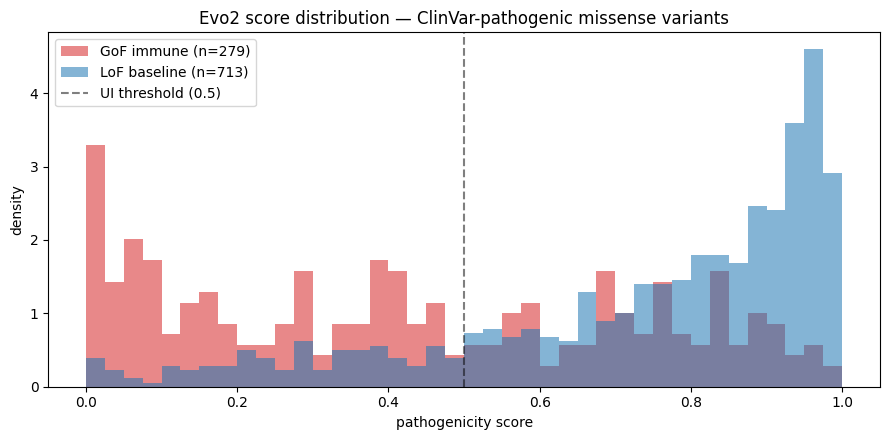

In [11]:
lof_ref = ("BRCA1", "TP53", "PTEN", "APC")

gof_scores = df[
    df.gene_name.isin(gof_genes)
    & df.label.isin(PATH_LABELS)
    & (df.consequence == "missense_variant")
]["pathogenicity"]

lof_scores = df[
    df.gene_name.isin(lof_ref)
    & df.label.isin(PATH_LABELS)
    & (df.consequence == "missense_variant")
]["pathogenicity"]

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0, 1, 41)
ax.hist(gof_scores, bins=bins, alpha=0.55, label=f"GoF immune (n={len(gof_scores)})", color="C3", density=True)
ax.hist(lof_scores, bins=bins, alpha=0.55, label=f"LoF baseline (n={len(lof_scores)})", color="C0", density=True)
ax.axvline(PATH_THRESHOLD, color="k", linestyle="--", alpha=0.5, label=f"UI threshold ({PATH_THRESHOLD})")
ax.set_xlabel("pathogenicity score")
ax.set_ylabel("density")
ax.set_title("Evo2 score distribution — ClinVar-pathogenic missense variants")
ax.legend()
plt.tight_layout()
plt.show()

The GoF distribution is bimodal with a large left peak below 0.3 — those are
the variants the viewer renders as "not pathogenic." The LoF distribution is
concentrated near 1.0, as expected.

## 8. Why the user saw what they saw

The user's original spot check covered 9 genes:

| Gene | FNR@0.5 | Mechanism | Expected viewer behavior |
|---|---|---|---|
| CD40LG | 8.8% | LoF | ✓ pathogenic (matches user's report) |
| XIAP | 0.0% | LoF | ✓ should work — user may have hit a specific edge-case variant |
| BTK | 4.0% | LoF | ✓ should work |
| WAS | 6.4% | LoF | ✓ should work |
| SH2D1A | 11.9% | LoF | ✓ mostly works |
| FOXP3 | 20.9% | LoF (IPEX) | ~1 in 5 missense FN |
| STAT1 | 62.8% | **GoF** | ✗ most pathogenic missense compressed |
| STAT3 | 28.1% | mixed | ✗ GoF variants compressed, LoF OK |
| NOD2 | 90.0% | **GoF** / low-penetrance | ✗ almost all pathogenic variants compressed |

If the user was looking at missense pathogenic variants — especially in STAT1,
STAT3, NOD2, NLRP3 — the score compression makes the viewer render them as VUS
or benign-range. That matches their observation almost exactly.

For XIAP/BTK/WAS, the viewer should work on aggregate, so the user likely hit
(a) specific variants that happened to fall in the minority FN tail, or
(b) variants with low-support ClinVar labels / conflicting classifications
that don't render as "pathogenic" regardless of score.

## 9. Summary

1. **17.3%** of ClinVar-pathogenic variants in the user's 26-gene immune panel
   are scored below the viewer's pathogenicity threshold — 5× the 3.3% rate
   on a standard LoF-dominant baseline.
2. **All** false negatives are `missense_variant`. LoF consequences (splice,
   nonsense, frameshift) are scored correctly.
3. The failure is concentrated in **GoF disease genes** (NLRP3, NOD2, STAT1,
   IFIH1; partially STAT3/FOXP3). These genes cause disease through activation-
   of-function missense at residues that evolution tolerates.
4. This is **not Evo2-specific**. AlphaMissense, REVEL, CADD, and PrimateAI
   all fail on the same variants — evolution/conservation-based predictors
   share this failure mode.
5. Actionable fix would require either (a) a GoF-aware supervised head,
   (b) per-gene calibration for known-GoF genes, or (c) a UI caveat for the
   curated GoF gene list. Not in scope for this audit.